In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [2]:
dataset_path = r"C:\Users\Nandy\dataset-resized\dataset-resized"

In [3]:
img_size = (150,150)
batch_size = 32
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [4]:
print(train_data.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [6]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

# Second Layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6,activation='softmax'))

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=15
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.2880 - loss: 1.6573 - val_accuracy: 0.3340 - val_loss: 1.5851
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.4328 - loss: 1.4144 - val_accuracy: 0.3598 - val_loss: 1.5023
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.4412 - loss: 1.3501 - val_accuracy: 0.4175 - val_loss: 1.4228
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.5079 - loss: 1.2602 - val_accuracy: 0.4135 - val_loss: 1.4459
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.5074 - loss: 1.2408 - val_accuracy: 0.4433 - val_loss: 1.3581
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.5558 - loss: 1.1813 - val_accuracy: 0.4473 - val_loss: 1.3496
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.5692 - loss: 1.1325 - val_accuracy: 0.4732 - val_loss: 1.3238
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.5939 - loss: 1.0861 - val_accuracy: 0.4573 - v

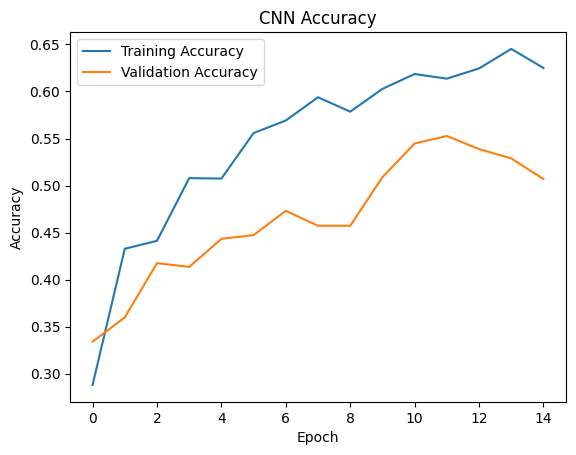

In [11]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.show()

In [12]:
model.save("waste_classifier.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


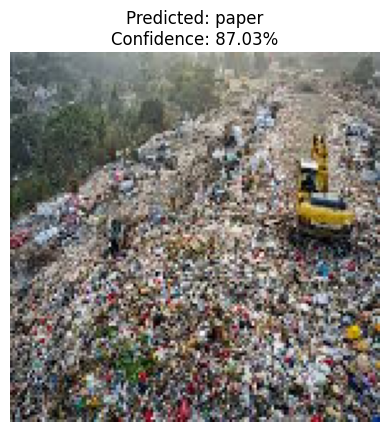

In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path of the test image
img_path = r"C:\Users\Nandy\test.jpeg"

# Load image
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Display image with prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

In [17]:
import numpy as np

prediction = model.predict(img_array)

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = classes[np.argmax(prediction)]

print("Predicted Category :", predicted_class)

# Waste Segregation
if predicted_class == "plastic":
    print("Segregation Bin : Plastic Recycling Bin")
elif predicted_class == "paper":
    print("Segregation Bin : Paper Recycling Bin")
elif predicted_class == "glass":
    print("Segregation Bin : Glass Recycling Bin")
elif predicted_class == "metal":
    print("Segregation Bin : Metal Recycling Bin")
elif predicted_class == "cardboard":
    print("Segregation Bin : Cardboard Recycling Bin")
else:
    print("Segregation Bin : General Waste Bin")

# Environmental AI
print("\nEnvironmental AI Suggestion:")
if predicted_class != "trash":
    print("This waste is recyclable. Dispose of it in the appropriate recycling bin.")
else:
    print("This waste is non-recyclable. Dispose of it in the general waste bin.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
Predicted Category : paper
Segregation Bin : Paper Recycling Bin

Environmental AI Suggestion:
This waste is recyclable. Dispose of it in the appropriate recycling bin.
